In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn
from functools import reduce
from operator import getitem
from utils.color_palettes import make_alternate_versions as make_color_palettes
seaborn.set_style('whitegrid')

# Always run from repo root regardless of notebook location
# _REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))
if os.path.basename(os.getcwd()) == "analysis":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

from utils.checkpoint_info import get_token_count


In [3]:
FINEWEB_PADDED = "rankme_fineweb_padded"
TRAINSET_PACKED_UNC_ONLY = "rankme_trainset_packed_unc"
TRAINSET_PACKED = "rankme_trainset_packed_40M"
KFAC_SMALL = "kfac_small"

In [12]:
def load_results(model_name: str, dataset_name: str = 'fineweb'):
    path = os.path.join('results', dataset_name, f'results_{model_name}.npy')
    try:
        res = np.load(path, allow_pickle=True).item()
    except FileNotFoundError as e:
        if '_' not in model_name:   # alternate result versions can be missed
            print(f"skipped: {path}")
            # raise e
        return None, None
    step_nums = sorted(res.keys())
    # print(res)
    return res, step_nums

HOOK_DEFAULTS = {
    # RANKME_TRAINSET_PACKED_: ('after_final_norm', 'A'),
    # 'rankme_fineweb_padded': ('after_final_norm', 'A'),
    # 'rankme_fineweb_padded': ('after_final_norm', 'A_centered'),
    # 'fineweb': (),
}

def _get_ys(res, step_nums, hook):
    if hook[-1] in ['log_det', 'log_det_A', 'log_det_G']:
        hook = (*hook, 2) # take smallest epsilon
    try:
        return [reduce(getitem, hook, res[s]) for s in step_nums]
    except TypeError as e:
        print(hook)
        raise e

def get_ys(dataset_name, res, step_nums, yvar, hook=None):
    if hook is None:
        hook = HOOK_DEFAULTS.get(dataset_name, ('after_final_norm', 'A_centered'))
    return _get_ys(res, step_nums, (*hook, yvar))

def get_xs_steps(model_name, step_nums):
    return step_nums

def get_xs_tokens(model_name, step_nums):
    return [get_token_count(model_name.split('_')[0], s) for s in step_nums]


def _parse_param_count(model_name):
    """Extract parameter count from model name (e.g. 'pythia-70m' -> 70e6, 'OLMo-2-0425-1B' -> 1e9)."""
    name = model_name.lower()
    if 'pythia' in name:
        size_str = model_name.split('pythia-')[-1].split('-deduped')[0]
    elif 'olmo' in name:
        size_str = model_name.split('-')[-1]
    else:
        raise ValueError(f"Cannot extract param count from {model_name}")
    multiplier = 1e6 if size_str[-1].lower() == 'm' else 1e9
    return float(size_str[:-1]) * multiplier


def get_xs_flops(model_name, step_nums):
    num_params = _parse_param_count(model_name)
    return [num_params * s for s in step_nums]


XVAR_FNS = {
    'steps': get_xs_steps,
    'tokens': get_xs_tokens,
    'flops': get_xs_flops,
}

XVAR_LABELS = {
    'steps': 'Steps',
    'tokens': 'Pretraining tokens',
    'flops': 'Flops',
    'isoflops': 'Parameters',
}

YVAR_LABELS = {
    'alpha': r'$\alpha$',
    'rankme': 'RankMe',
}

base_colors = [
    'turquoise', 'turquoise',
    'cornflowerblue', 'cornflowerblue',
    'lime', 'lime',
    'darkgreen', 'darkgreen',
    'gold', 'gold',
    'dodgerblue', 'dodgerblue',
    'magenta', 'magenta',
    'deeppink', 'deeppink',
    'purple', 'purple',
    'brown', 'brown',
    'blue',
    'red',
]

model_name_options = [
    'pythia-14m', 'pythia-14m-deduped',
    'pythia-31m', 'pythia-31m-deduped',
    'pythia-70m', 'pythia-70m-deduped',
    'pythia-160m', 'pythia-160m-deduped',
    'pythia-410m', 'pythia-410m-deduped',
    'pythia-1b', 'pythia-1b-deduped',
    'pythia-1.4b', 'pythia-1.4b-deduped',
    'pythia-2.8b', 'pythia-2.8b-deduped',
    'pythia-6.9b', 'pythia-6.9b-deduped',
    'pythia-12b', 'pythia-12b-deduped',
    'OLMo-2-0425-1B',
    'OLMo-2-1124-7B',
]

def get_ls(model_name: str, xvar=None):
    if xvar == 'isoflops':
        return '*' if 'deduped' in model_name else 's'

    ls_exceptions = {'_': '-.', 'deduped': '--'}
    for substring, ls in ls_exceptions.items():
        if substring in model_name:
            return ls
    return '-'

def get_model_label(model_name: str):
    parts = model_name.replace('_','-').split('-')

    if parts[0] == 'pythia':
        if len(parts) > 2:
            if parts[2] == 'deduped':
                parts.pop(2)
                parts[1] += 'd'
        parts = [parts[0].capitalize(), parts[1].upper(), *parts[2:]]

    if parts[0] == 'OLMo' and parts[1] == '2':
        parts = ['OLMo-2', parts[3], *parts[4:]]

    return ' '.join(parts)


In [5]:
def plot_model_training(model_name: str, source: tuple[str], xvar: str = 'tokens',
                        yvar: str = 'alpha', color: str = 'k', marker: str = 'o',
                        label_source: bool = False, label_model: bool = True, alternates: list[str] = []):
    source_file, hook, source_label, *custom_yvar = source
    if custom_yvar:
        yvar = custom_yvar[0]
    for model_name in [model_name, *(model_name+f'_{alt}' for alt in alternates)]:

        res, step_nums = load_results(model_name, dataset_name=source_file)
        if res is None:
            continue

        xs = XVAR_FNS[xvar](model_name, step_nums)
        ys = get_ys(source_file, res, step_nums, yvar, hook=hook)
        ls = get_ls(model_name)

        label = (
            f'{get_model_label(model_name)}' * label_model
          + f' - '                           * label_model * label_source
          + f'{source_label}'                * label_source
        )

        plt.plot(xs, ys, marker=marker, color=color, ls=ls, lw=3, label=label)

_grid = None

def grid_start(ncols=2, figsize=None):
    global _grid
    _grid = dict(ncols=ncols, figsize=figsize, calls=[])

def grid_show():
    global _grid
    calls = _grid['calls']
    ncols = _grid['ncols']
    nrows = (len(calls) + ncols - 1) // ncols
    figsize = _grid['figsize'] or (7 * ncols, 5 * nrows)
    _grid = None

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).flatten()
    for i, (args, kwargs) in enumerate(calls):
        plot_group(*args, ax=axes[i], **kwargs)
    for ax in axes[len(calls):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

def plot_group(
    xvar: str,
    yvar: str,
    data_sources: list[str],
    model_names: list[str],
    ylog: bool = False,
    ax=None,
    **kwargs
):
    if _grid is not None and ax is None:
        _grid['calls'].append(((xvar, yvar, data_sources, model_names, ylog), kwargs))
        return

    palettes = make_color_palettes(
        base_colors, len(data_sources), method="hue_shift",
        shift=0.11, light_base=0.85
    )

    if ax is not None:
        plt.sca(ax)

    for midx, model_name in enumerate(model_names):
        for didx, data_source in enumerate(data_sources):
            color = palettes[didx][model_name_options.index(model_name)]
            plot_model_training(model_name, data_source,
                                xvar=xvar, yvar=yvar,
                                color=color,
                                label_source=len(data_sources)>1 or len(model_names) <= 1,
                                label_model=len(model_names)>1,
                                **kwargs)

    plt.xscale('log')
    if ylog:
        plt.yscale('log')
    plt.xlabel(XVAR_LABELS[xvar], fontsize=14)
    plt.ylabel(YVAR_LABELS.get(yvar, yvar), fontsize=14)
    plt.legend()
    if ax is None:
        plt.show()


skipped: results/rankme_trainset_packed_40M/results_pythia-6.9b-deduped.npy
skipped: results/rankme_trainset_packed_40M/results_OLMo-2-1124-7B.npy
skipped: results/rankme_trainset_packed_40M/results_pythia-6.9b-deduped.npy
skipped: results/rankme_trainset_packed_40M/results_OLMo-2-1124-7B.npy


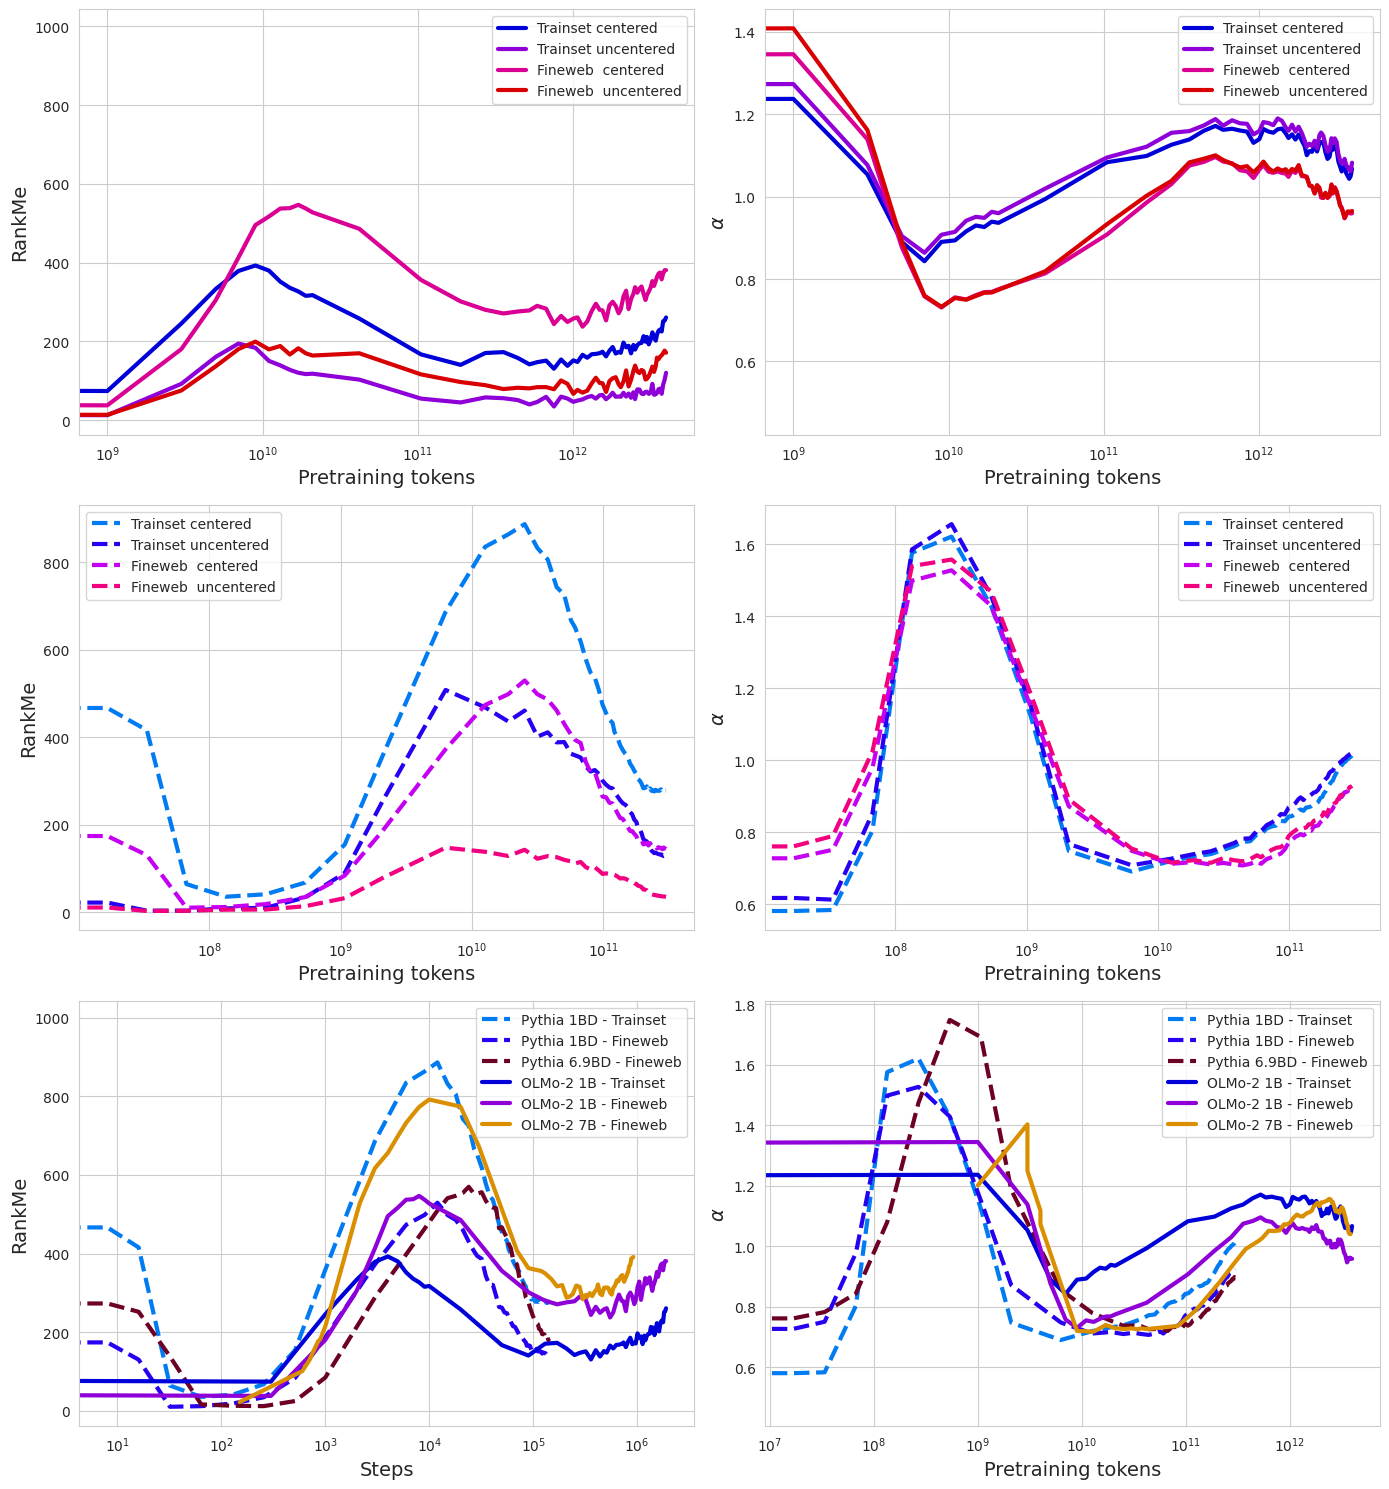

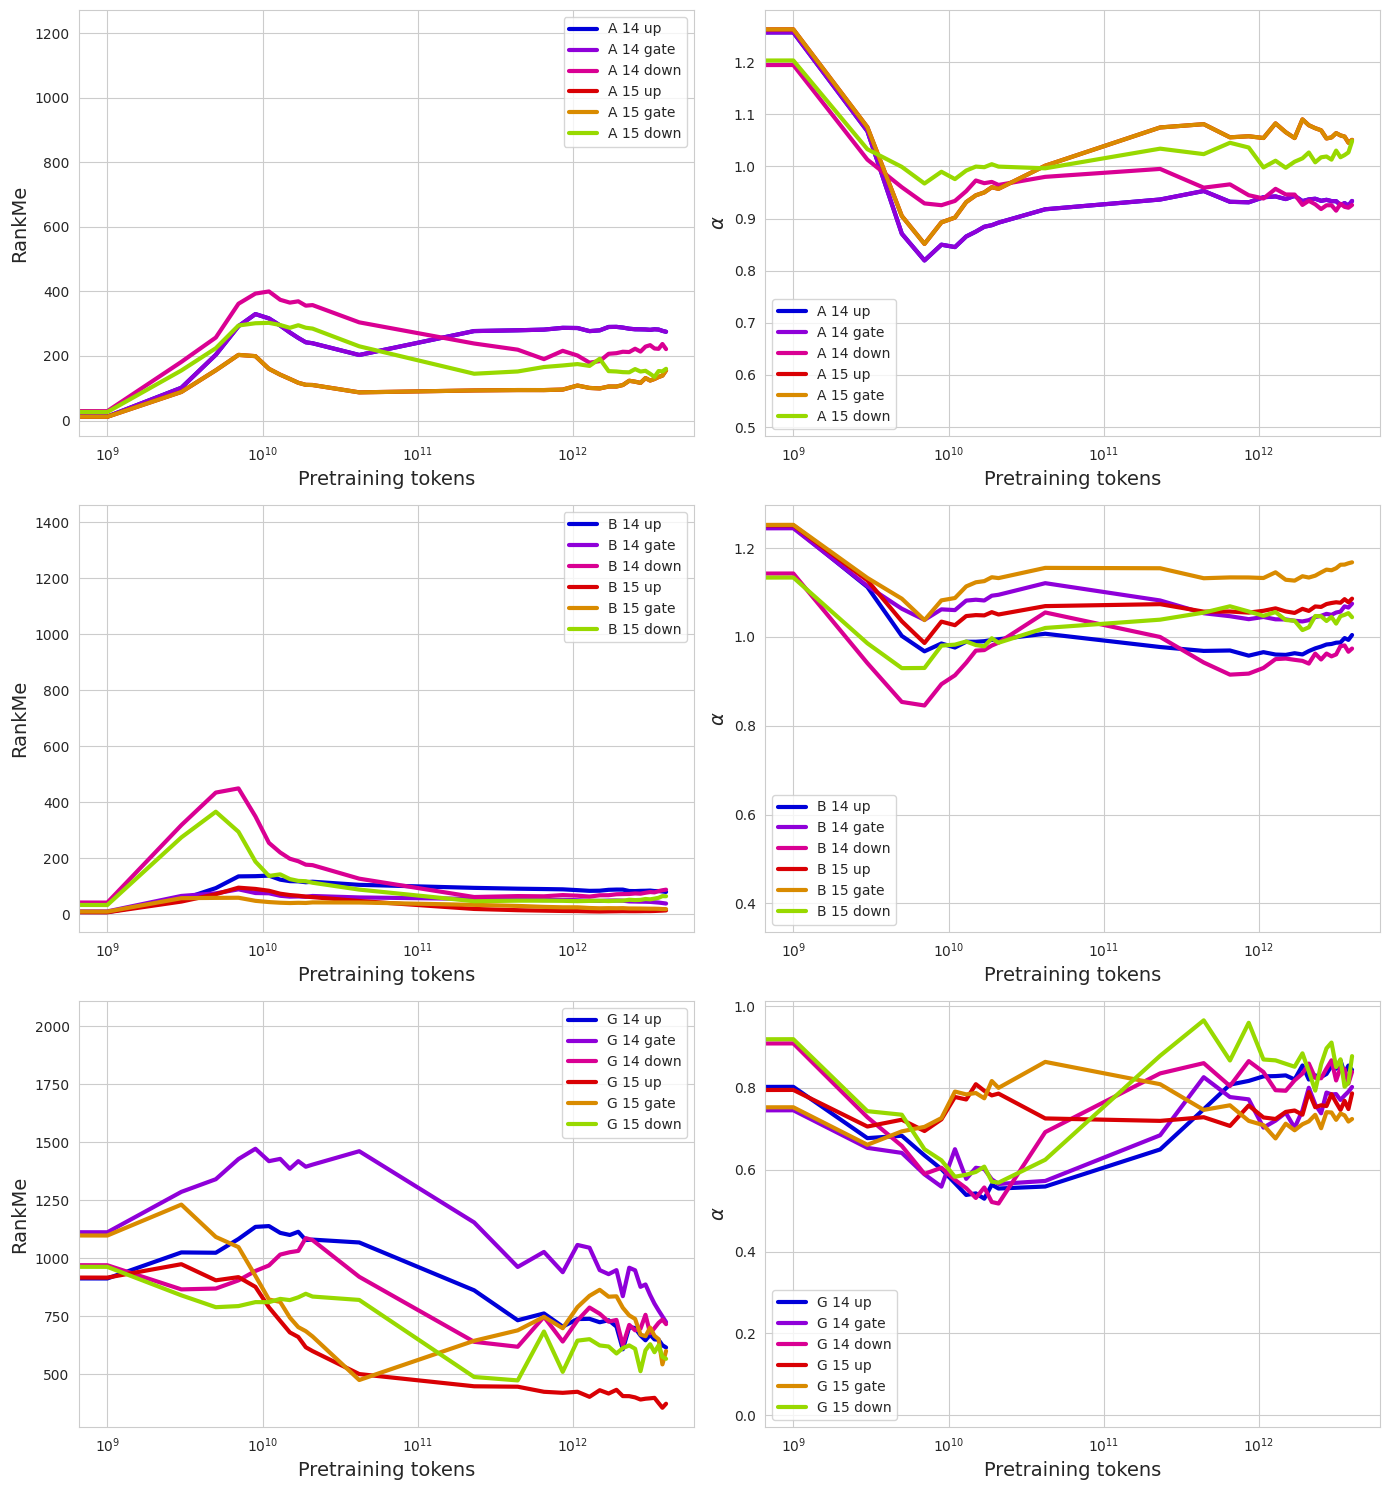

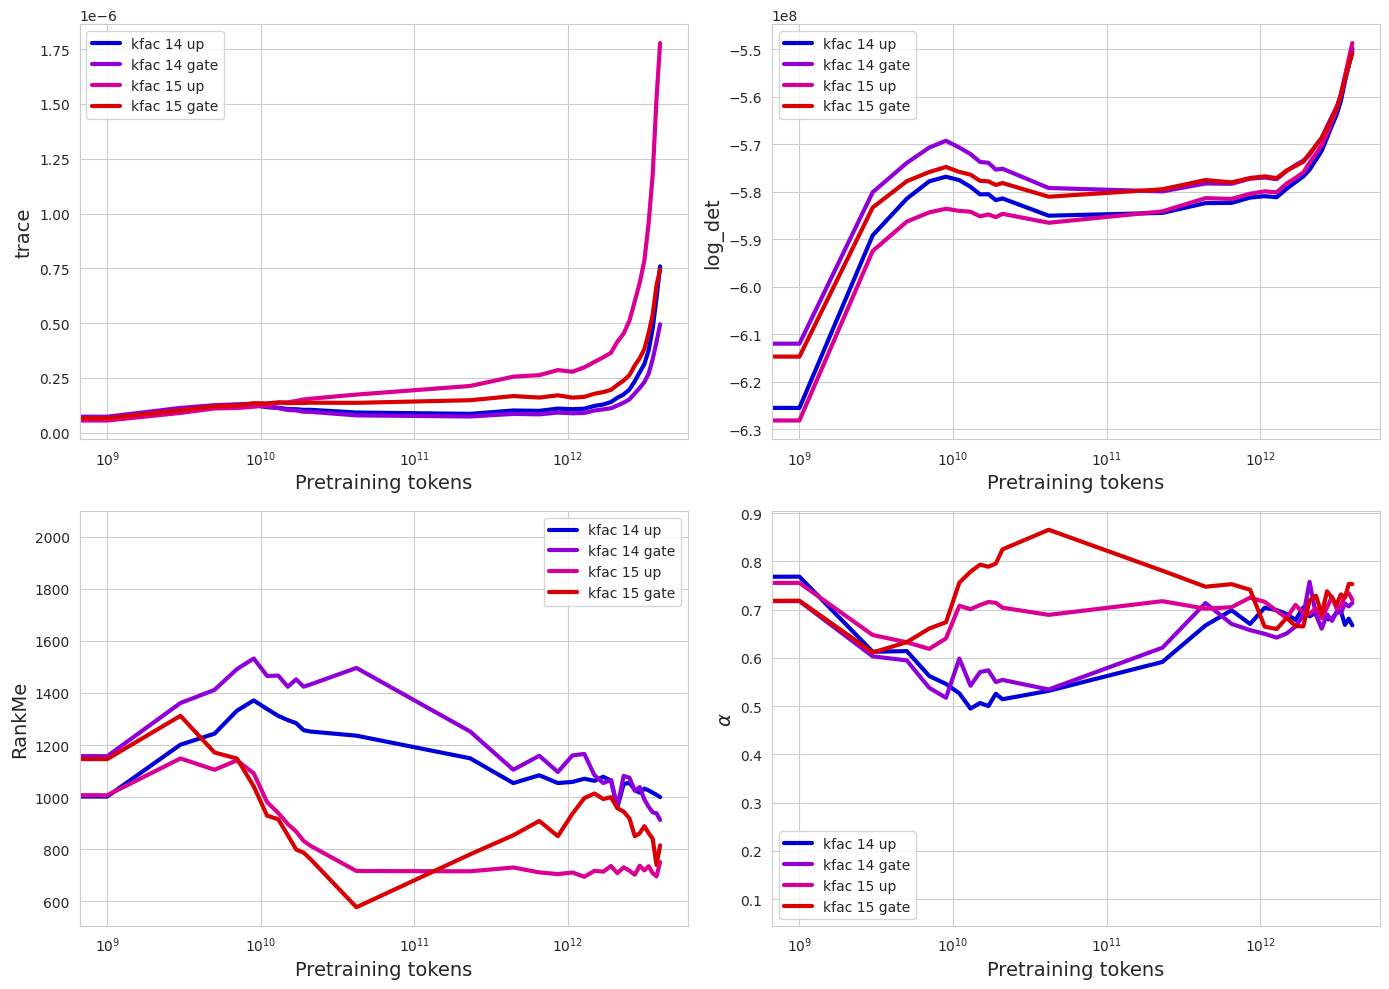

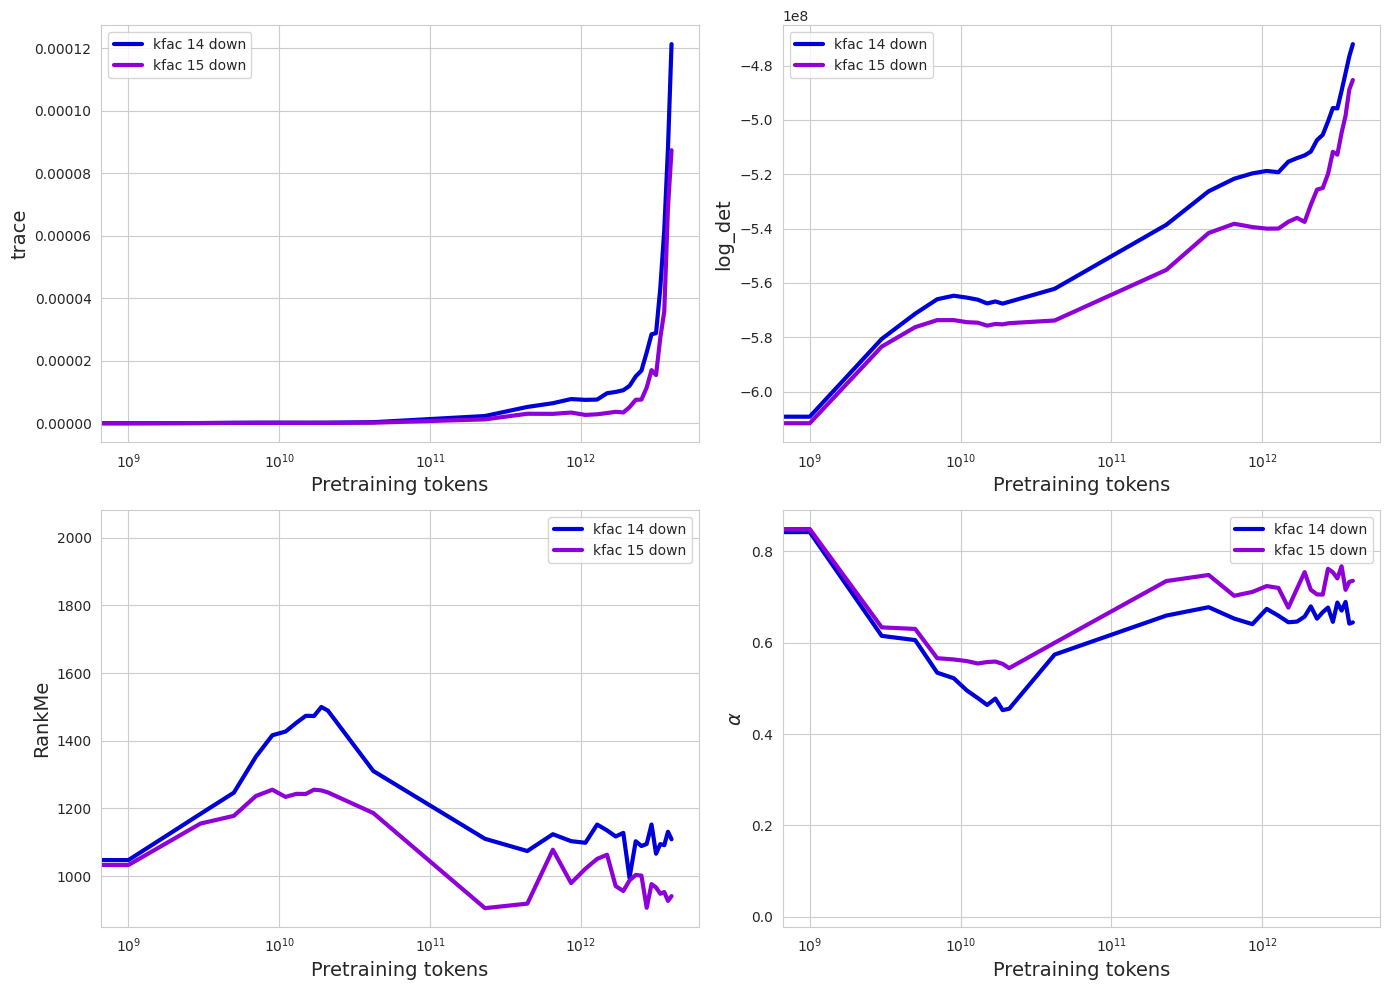

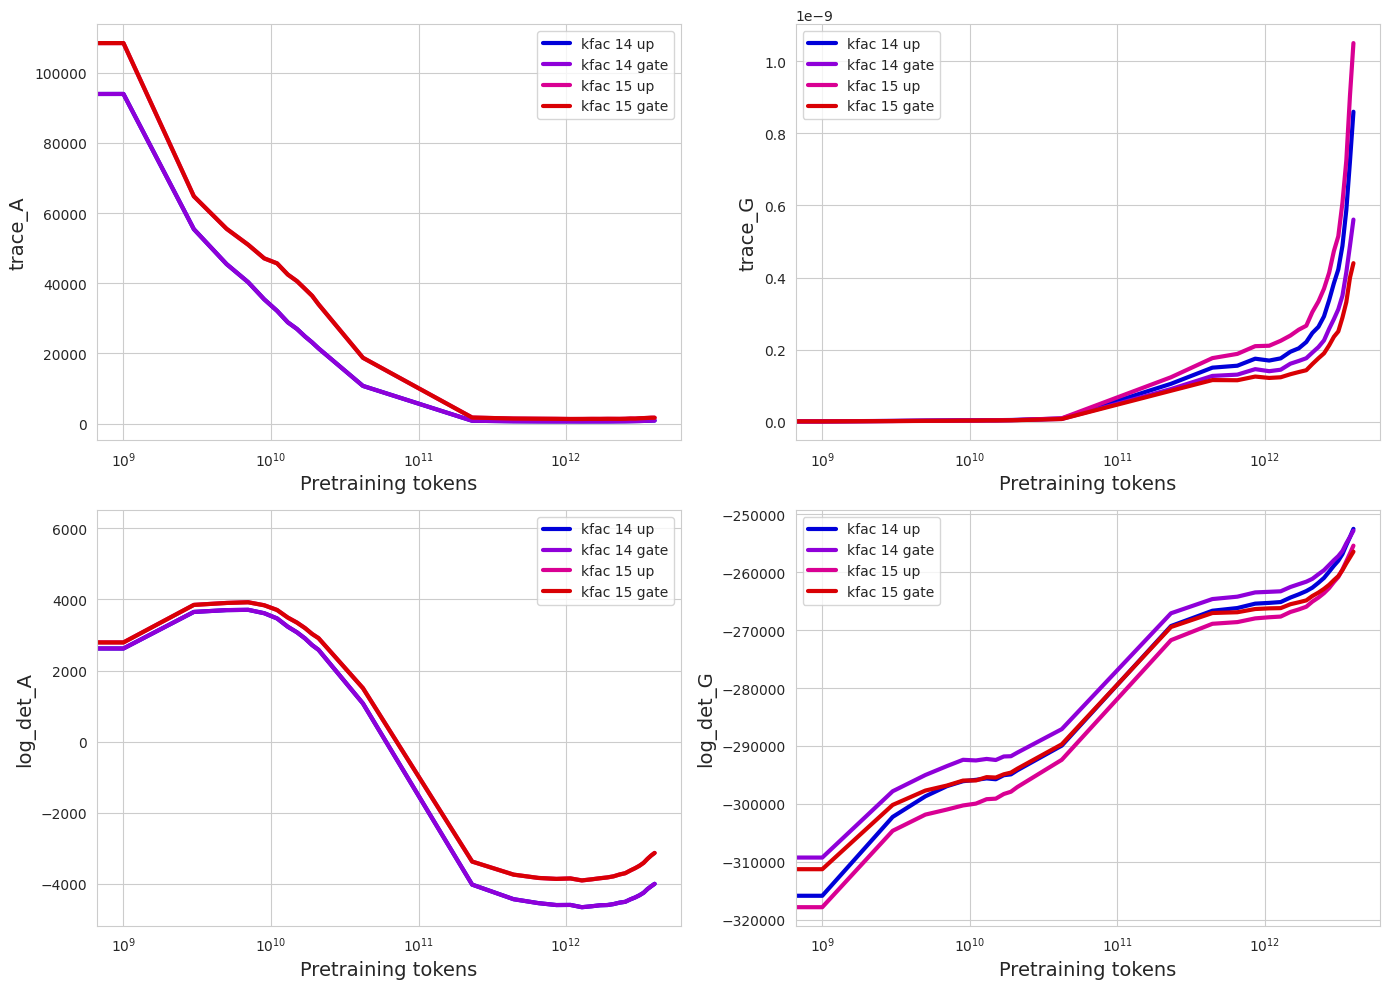

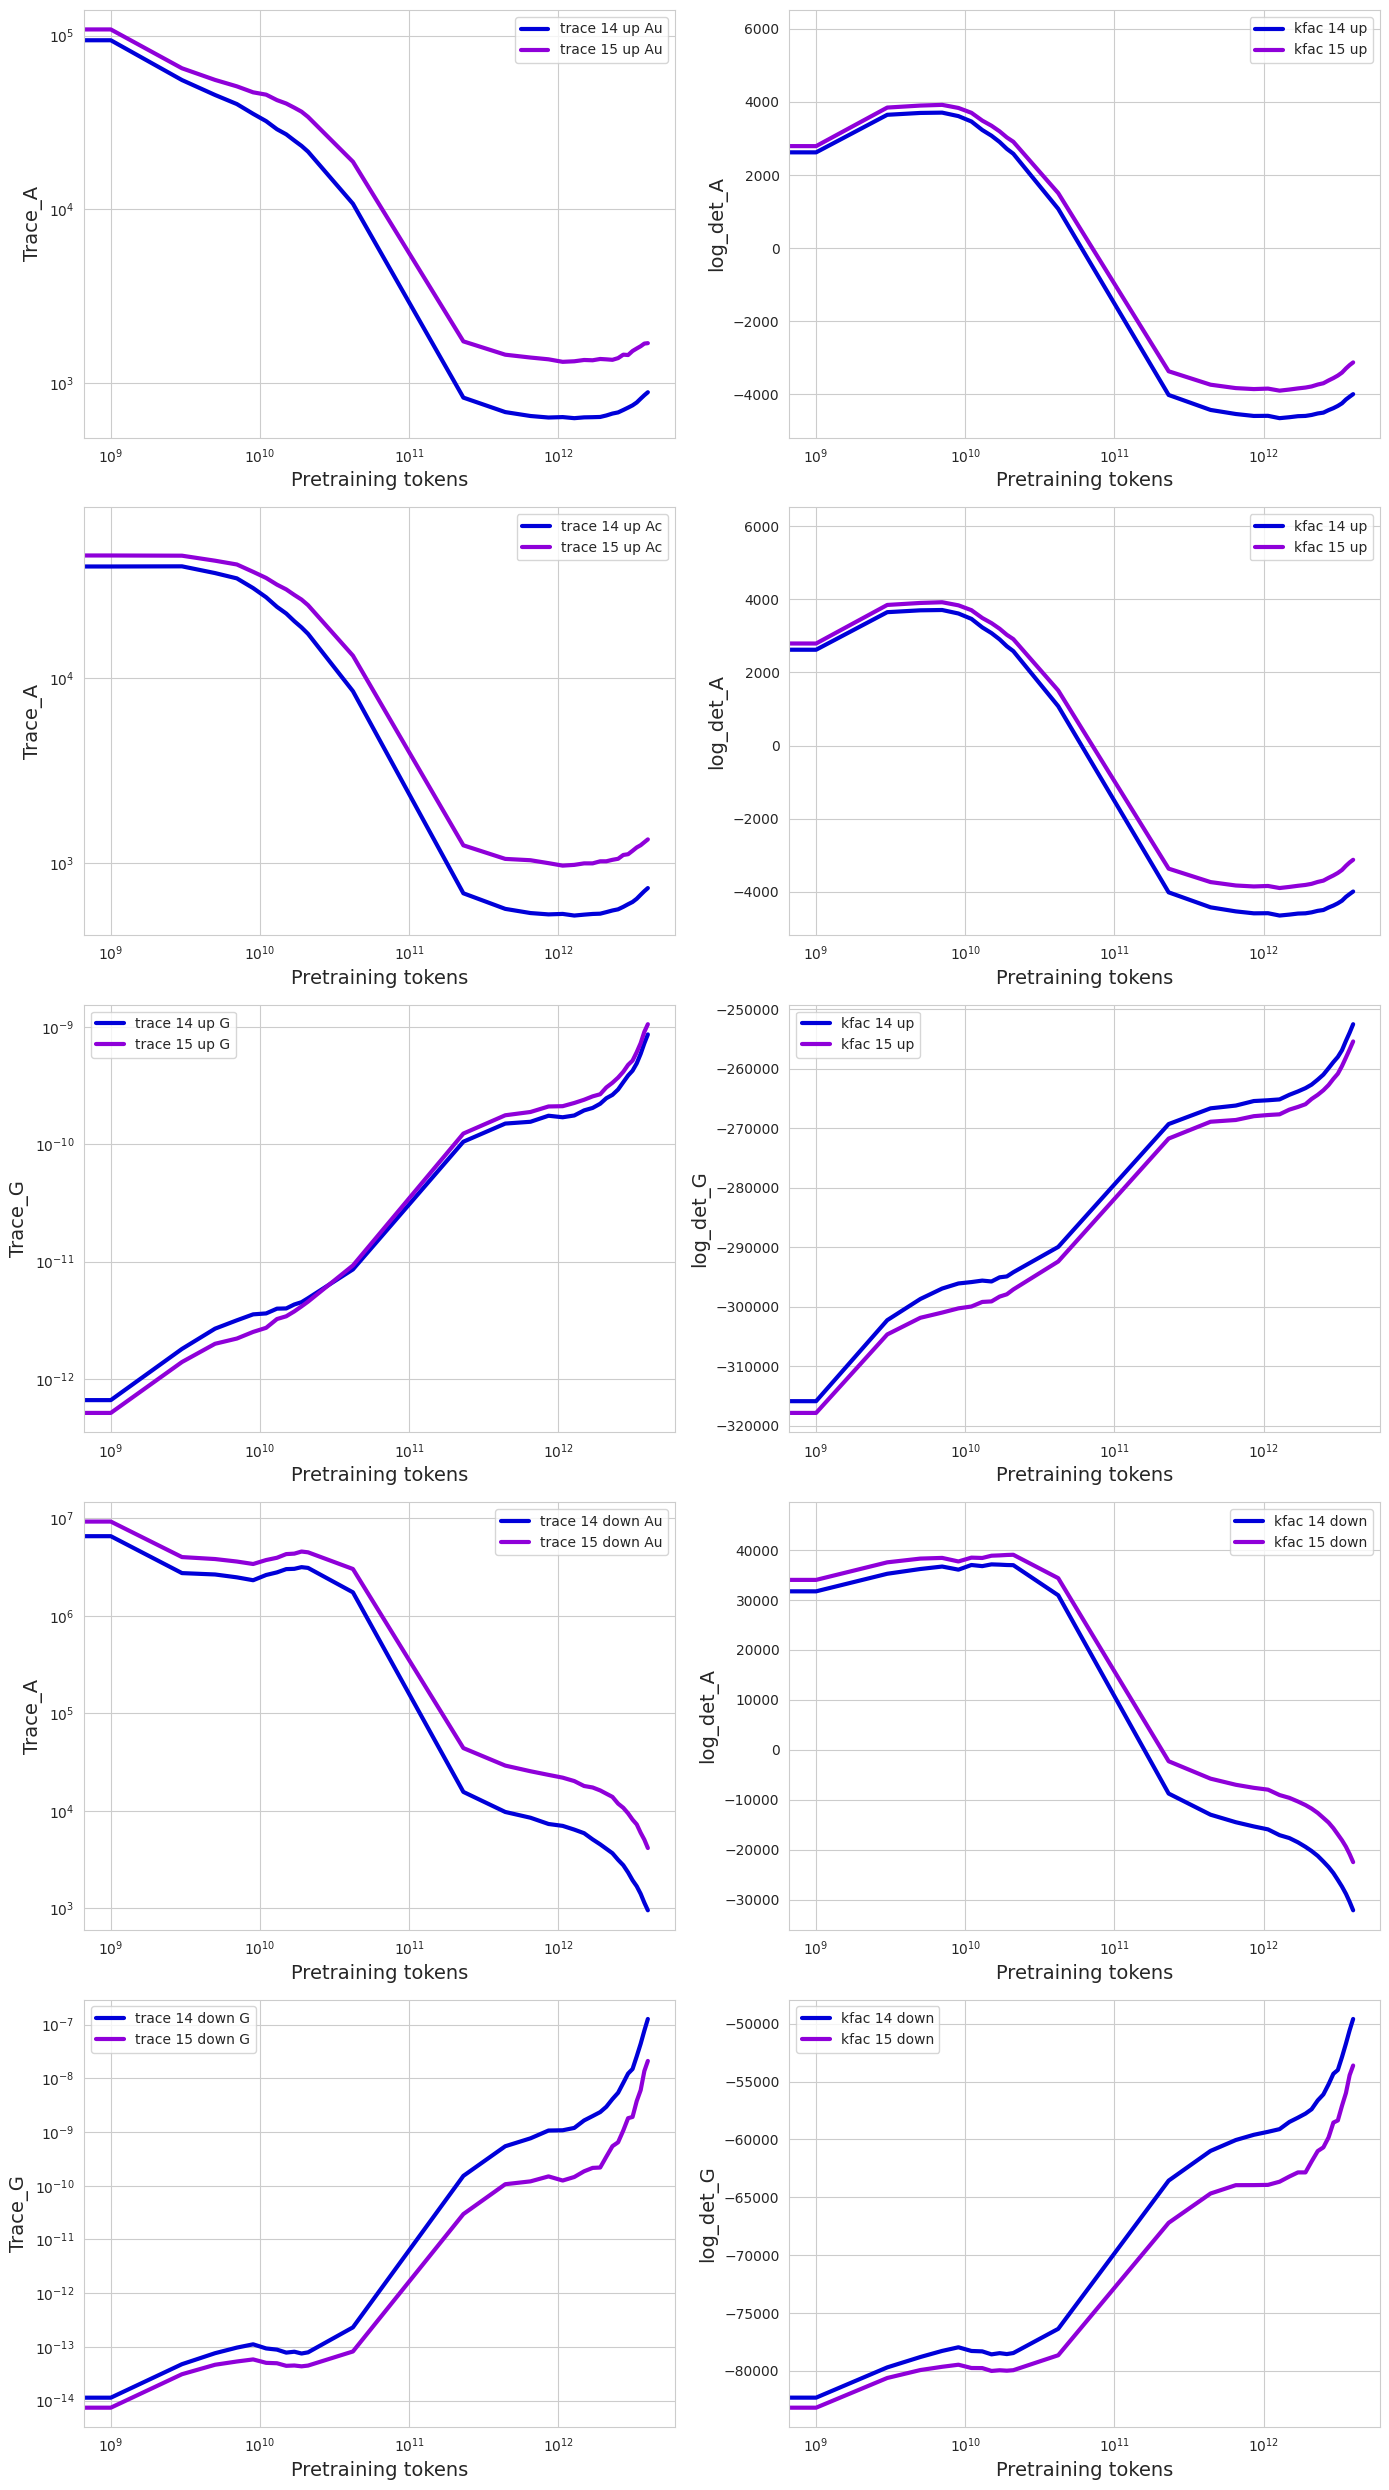

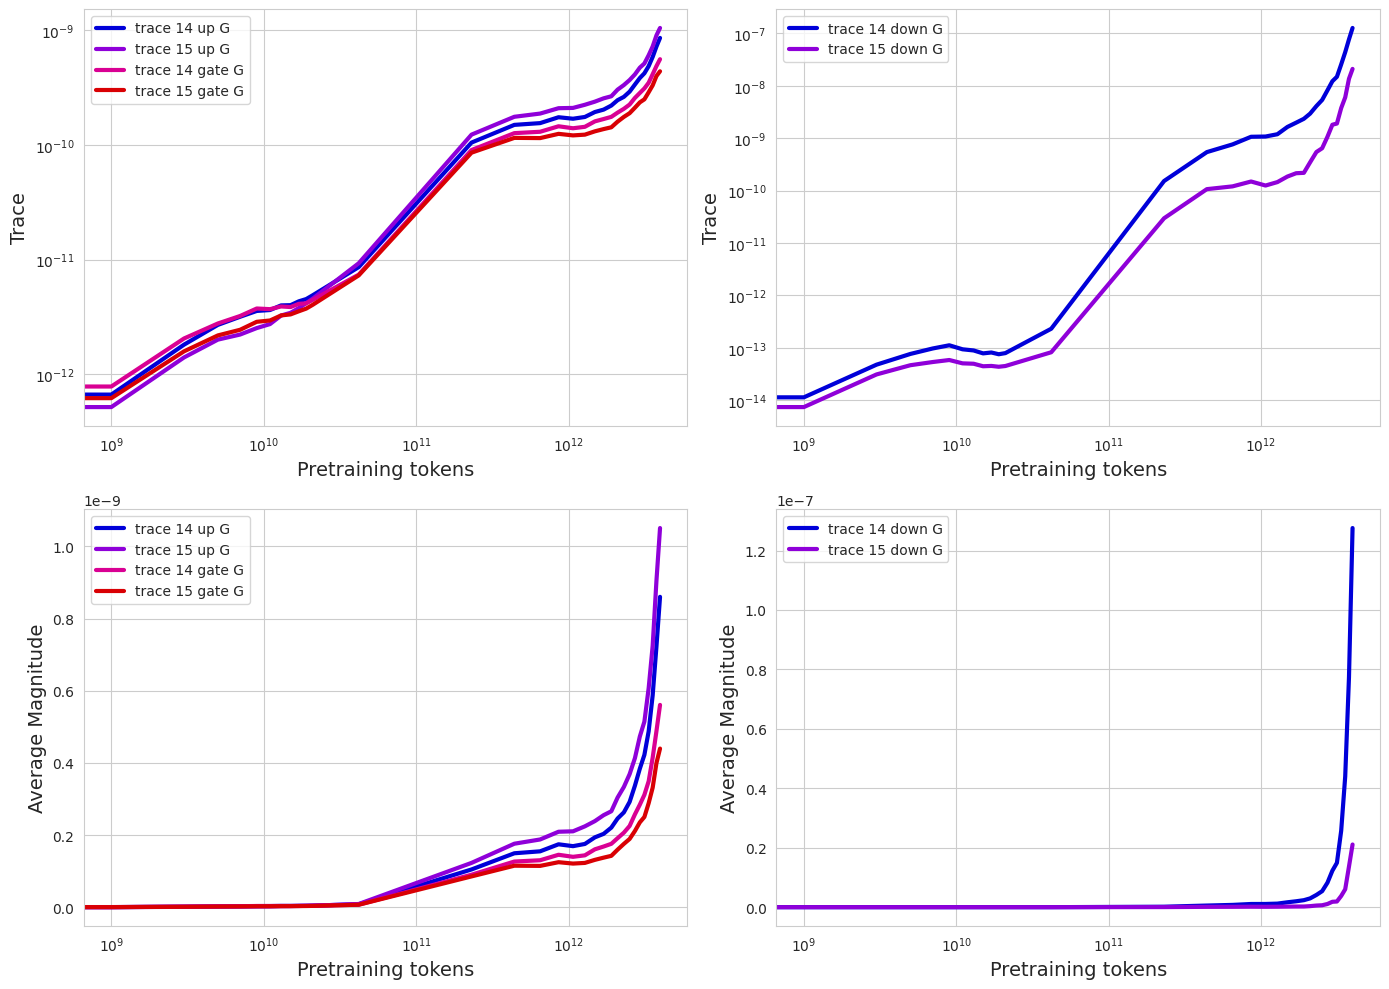

In [13]:
filter_model_names = [
    # 'pythia-14m-deduped',
    # 'pythia-31m-deduped',
    # 'pythia-70m-deduped',
    # 'pythia-160m-deduped',
    # 'pythia-410m-deduped',
    'pythia-1b-deduped',
    # 'pythia-1.4b-deduped',
    # 'pythia-2.8b-deduped',
    'pythia-6.9b-deduped',
    # 'pythia-12b-deduped',
    # 'pythia-14m',
    # 'pythia-31m',
    # 'pythia-70m',
    # 'pythia-160m',
    # 'pythia-410m',
    # 'pythia-1b',
    # 'pythia-1.4b',
    # 'pythia-2.8b',
    # 'pythia-6.9b',
    # 'pythia-12b',
    'OLMo-2-0425-1B',
    'OLMo-2-1124-7B',
]

alternates = [
    # '5k'
]

AFN_AC = ('after_final_norm', 'A_centered')
AFN_AU = ('after_final_norm', 'A')

U14_AC = ('blk14.up', 'A_centered')
G14_AC = ('blk14.gate', 'A_centered')
D14_AC = ('blk14.down', 'A_centered')

U15_AC = ('blk15.up', 'A_centered')
G15_AC = ('blk15.gate', 'A_centered')
D15_AC = ('blk15.down', 'A_centered')

U14_AU = ('blk14.up', 'A')
G14_AU = ('blk14.gate', 'A')
D14_AU = ('blk14.down', 'A')

U15_AU = ('blk15.up', 'A')
G15_AU = ('blk15.gate', 'A')
D15_AU = ('blk15.down', 'A')

U14_BU = ('blk14.up', 'B')
G14_BU = ('blk14.gate', 'B')
D14_BU = ('blk14.down', 'B')

U15_BU = ('blk15.up', 'B')
G15_BU = ('blk15.gate', 'B')
D15_BU = ('blk15.down', 'B')

U14_GU = ('blk14.up', 'G')
G14_GU = ('blk14.gate', 'G')
D14_GU = ('blk14.down', 'G')

U15_GU = ('blk15.up', 'G')
G15_GU = ('blk15.gate', 'G')
D15_GU = ('blk15.down', 'G')

U14_KF = ('blk14.up', 'kfac')
G14_KF = ('blk14.gate', 'kfac')
D14_KF = ('blk14.down', 'kfac')
U15_KF = ('blk15.up', 'kfac')
G15_KF = ('blk15.gate', 'kfac')
D15_KF = ('blk15.down', 'kfac')

data_sources_1 = [
#   Data File          Hook      Label
    (TRAINSET_PACKED,   AFN_AC,   'Trainset centered'),
    (TRAINSET_PACKED,   AFN_AU,   'Trainset uncentered'),
    (FINEWEB_PADDED,    AFN_AC,   'Fineweb  centered'),
    (FINEWEB_PADDED,    AFN_AU,   'Fineweb  uncentered'),
]

data_sources_2 = [
#   Data File          Hook      Label
    (TRAINSET_PACKED,   AFN_AC,   'Trainset'),
    (FINEWEB_PADDED,    AFN_AC,   'Fineweb'),
]

mlp_ac = [
    (KFAC_SMALL,   U14_AC,   'Ac 14 up'),
    (KFAC_SMALL,   G14_AC,   'Ac 14 gate'),
    (KFAC_SMALL,   D14_AC,   'Ac 14 down'),
    (KFAC_SMALL,   U15_AC,   'Ac 15 up'),
    (KFAC_SMALL,   G15_AC,   'Ac 15 gate'),
    (KFAC_SMALL,   D15_AC,   'Ac 15 down'),
]
mlp_au = [
    (KFAC_SMALL,   U14_AU,   'A 14 up'),
    (KFAC_SMALL,   G14_AU,   'A 14 gate'),
    (KFAC_SMALL,   D14_AU,   'A 14 down'),
    (KFAC_SMALL,   U15_AU,   'A 15 up'),
    (KFAC_SMALL,   G15_AU,   'A 15 gate'),
    (KFAC_SMALL,   D15_AU,   'A 15 down'),
]
mlp_bu = [
    (KFAC_SMALL,   U14_BU,   'B 14 up'),
    (KFAC_SMALL,   G14_BU,   'B 14 gate'),
    (KFAC_SMALL,   D14_BU,   'B 14 down'),
    (KFAC_SMALL,   U15_BU,   'B 15 up'),
    (KFAC_SMALL,   G15_BU,   'B 15 gate'),
    (KFAC_SMALL,   D15_BU,   'B 15 down'),
]
mlp_gu = [
    (KFAC_SMALL,   U14_GU,   'G 14 up'),
    (KFAC_SMALL,   G14_GU,   'G 14 gate'),
    (KFAC_SMALL,   D14_GU,   'G 14 down'),
    (KFAC_SMALL,   U15_GU,   'G 15 up'),
    (KFAC_SMALL,   G15_GU,   'G 15 gate'),
    (KFAC_SMALL,   D15_GU,   'G 15 down'),
]

mlp_kf = [
    (KFAC_SMALL,   U14_KF,   'kfac 14 up'),
    (KFAC_SMALL,   G14_KF,   'kfac 14 gate'),
    (KFAC_SMALL,   U15_KF,   'kfac 15 up'),
    (KFAC_SMALL,   G15_KF,   'kfac 15 gate'),
]
mlp_kfd = [
    (KFAC_SMALL,   D14_KF,   'kfac 14 down'),
    (KFAC_SMALL,   D15_KF,   'kfac 15 down'),
]
traces_Ac = (lambda l, h : [
    (KFAC_SMALL,   (f'blk{l}.{h}', 'A_centered'), f'trace {l} {h} Ac',  'trace'),
])
traces_A = (lambda l, h : [
    (KFAC_SMALL,   (f'blk{l}.{h}', 'A'),          f'trace {l} {h} Au',  'trace'),
    # (KFAC_SMALL,   (f'blk{l}.{h}', 'kfac'),       f'trace {l} {h} Akf', 'trace_A'),
])
traces_G = (lambda l, h : [
    (KFAC_SMALL,   (f'blk{l}.{h}', 'G', ),  f'trace {l} {h} G',   'trace'),
    # (KFAC_SMALL,   (f'blk{l}.{h}', 'kfac'), f'trace {l} {h} Gkf', 'trace_G'),
])
traces_B = (lambda l, h : [
    (KFAC_SMALL,   (f'blk{l}.{h}', 'B'), f'trace {l} {h} B', 'trace'),
])
mags_A = (lambda l, h : [
    # (KFAC_SMALL,   (f'blk{l}.{h}', 'A_centered'), f'avg {l} {h} Ac', 'avg_magnitude'),
    (KFAC_SMALL,   (f'blk{l}.{h}', 'A'),          f'avg {l} {h} Au', 'avg_magnitude'),
])
mags_B = (lambda l, h : [
    (KFAC_SMALL,   (f'blk{l}.{h}', 'B'),          f'avg {l} {h} B',  'avg_magnitude'),
])
mags_G = (lambda l, h : [
    (KFAC_SMALL,   (f'blk{l}.{h}', 'G'),          f'avg {l} {h} G',  'avg_magnitude'),
])

####        #        #        #        #        #        #        ####
####     "Tracing the representation geometry.." reproduction     ####
####        #        #        #        #        #        #        ####
grid_start(ncols=2)
plot_group('tokens', 'rankme', data_sources_1, ['OLMo-2-0425-1B'], alternates=alternates, marker='')
plot_group('tokens', 'alpha', data_sources_1, ['OLMo-2-0425-1B'], alternates=alternates, marker='')

plot_group('tokens', 'rankme', data_sources_1, ['pythia-1b-deduped'], alternates=alternates, marker='')
plot_group('tokens', 'alpha', data_sources_1, ['pythia-1b-deduped'], alternates=alternates, marker='')

plot_group('steps', 'rankme', data_sources_2, filter_model_names, alternates=alternates, marker='')
plot_group('tokens', 'alpha', data_sources_2, filter_model_names, alternates=alternates, marker='')
grid_show()


####        #        #        #        #        #        #        ####
####                          MLP RankMe                          ####
####        #        #        #        #        #        #        ####
grid_start(ncols=2)
plot_group('tokens', 'rankme', mlp_au, ['OLMo-2-0425-1B'], marker='')
plot_group('tokens', 'alpha', mlp_au, ['OLMo-2-0425-1B'], marker='')
plot_group('tokens', 'rankme', mlp_bu, ['OLMo-2-0425-1B'], marker='')
plot_group('tokens', 'alpha', mlp_bu, ['OLMo-2-0425-1B'], marker='')
plot_group('tokens', 'rankme', mlp_gu, ['OLMo-2-0425-1B'], marker='')
plot_group('tokens', 'alpha', mlp_gu, ['OLMo-2-0425-1B'], marker='')
grid_show()


####        #        #        #        #        #        #        ####
####                          KFAC Stuff                          ####
####        #        #        #        #        #        #        ####
grid_start(ncols=2)
plot_group('tokens', 'trace', mlp_kf, ['OLMo-2-0425-1B'], marker='')
plot_group('tokens', 'log_det', mlp_kf, ['OLMo-2-0425-1B'], marker='')
plot_group('tokens', 'rankme', mlp_kf, ['OLMo-2-0425-1B'], marker='')
plot_group('tokens', 'alpha', mlp_kf, ['OLMo-2-0425-1B'], marker='')
grid_show()

grid_start(ncols=2)
plot_group('tokens', 'trace', mlp_kfd, ['OLMo-2-0425-1B'], marker='')
plot_group('tokens', 'log_det', mlp_kfd, ['OLMo-2-0425-1B'], marker='')
plot_group('tokens', 'rankme', mlp_kfd, ['OLMo-2-0425-1B'], marker='')
plot_group('tokens', 'alpha', mlp_kfd, ['OLMo-2-0425-1B'], marker='')
grid_show()


####        #        #        #        #        #        #        ####
####                          Magnitudes                          ####
####        #        #        #        #        #        #        ####
grid_start(ncols=2)
plot_group('tokens', 'trace_A', mlp_kf, ['OLMo-2-0425-1B'], marker='')
plot_group('tokens', 'trace_G', mlp_kf, ['OLMo-2-0425-1B'], marker='')
plot_group('tokens', 'log_det_A', mlp_kf, ['OLMo-2-0425-1B'], marker='')
plot_group('tokens', 'log_det_G', mlp_kf, ['OLMo-2-0425-1B'], marker='')
grid_show()

grid_start(ncols=2)
plot_group('tokens', 'Trace_A', [*traces_A(14,'up'), *traces_A(15,'up')], ['OLMo-2-0425-1B'], marker='', ylog=True)
plot_group('tokens', 'log_det_A', mlp_kf[::2], ['OLMo-2-0425-1B'], marker='')
plot_group('tokens', 'Trace_A', [*traces_Ac(14,'up'), *traces_Ac(15,'up')], ['OLMo-2-0425-1B'], marker='', ylog=True)
plot_group('tokens', 'log_det_A', mlp_kf[::2], ['OLMo-2-0425-1B'], marker='')
plot_group('tokens', 'Trace_G', [*traces_G(14,'up'), *traces_G(15,'up')], ['OLMo-2-0425-1B'], marker='', ylog=True)
plot_group('tokens', 'log_det_G', mlp_kf[::2], ['OLMo-2-0425-1B'], marker='')
# plot_group('tokens', 'Trace_B', [*traces_B(14,'gate'), *traces_B(15,'gate')], ['OLMo-2-0425-1B'], marker='', ylog=True)
plot_group('tokens', 'Trace_A', [*traces_A(14,'down'),*traces_A(15,'down')], ['OLMo-2-0425-1B'], marker='', ylog=True)
plot_group('tokens', 'log_det_A', mlp_kfd, ['OLMo-2-0425-1B'], marker='')
plot_group('tokens', 'Trace_G', [*traces_G(14,'down'),*traces_G(15,'down')], ['OLMo-2-0425-1B'], marker='', ylog=True)
plot_group('tokens', 'log_det_G', mlp_kfd, ['OLMo-2-0425-1B'], marker='')
# plot_group('tokens', 'Trace', [*traces_B(15,'down')], ['OLMo-2-0425-1B'], marker='', ylog=True)
grid_show()

grid_start(ncols=2)
plot_group('tokens', 'Trace',
           [*traces_G(14,'up'), *traces_G(15,'up'),
           *traces_G(14,'gate'), *traces_G(15,'gate')],
           ['OLMo-2-0425-1B'], marker='', ylog=True)

plot_group('tokens', 'Trace',
           [*traces_G(14,'down'),*traces_G(15,'down')],
           ['OLMo-2-0425-1B'], marker='', ylog=True)

plot_group('tokens', 'Average Magnitude',
           [*traces_G(14,'up'), *traces_G(15,'up'),
            *traces_G(14,'gate'), *traces_G(15,'gate')],
           ['OLMo-2-0425-1B'], marker='')

plot_group('tokens', 'Average Magnitude',
           [*traces_G(14,'down'), *traces_G(15,'down')],
           ['OLMo-2-0425-1B'], marker='')

grid_show()
